2026/09/20, M. Ohno  
This module and its accompanying documentation were developed with the support of Cursor’s AI-assisted tools.  

mol-aspectでは「妥当な構造の分子」を入力することを前提としている。この「妥当な構造の分子」を生成する手法は任意だが、RDKitを用いて簡便に作成する例を以下に記す。   
もちろん、手法はこれに限る必要はなく、GaussianやPsy4、何らかのMDなどによって生成したものを用いることもできる。  

### 参考文献  
RDKitによる配座異性体の発生や、安定構造の取得については、以下で詳しい記事を書いておられ、大変参考になります。  

有機合成化学者のための計算化学・ケモインフォマティクス入門
化学の新しいカタチ,  
https://future-chem.com/rdkit-conformer/

### 参考例　　


In [1]:
# pip installせず、colneして使う場合は、以下のpath付与をおこなう。  

import os
import sys

sys.path.append(os.path.abspath(os.path.join("..", "src")))

### 参考  
**例1**  
未成型座標の3Dファイルや、2Dの配座ファイルから「一つだけ構造発生＋その構造を最適化」させる一例を記す。

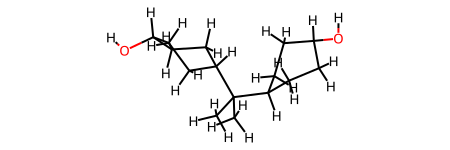

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem

suppl = Chem.SDMolSupplier("./sample_data/Structure2D_COMPOUND_CID_94932.sdf", removeHs=False)
mol_0 = suppl[0] # 今回は一化合物だが、SDFファイルの最初の化合物を取り出している  
target_mol = Chem.AddHs(mol_0) # 水素の欠損がある場会に備えて
status_3D = AllChem.EmbedMolecule(target_mol) # 立体配座を生成, status_3D = 0で成功
status_optimize = AllChem.UFFOptimizeMolecule(target_mol)

# 立体配座生成、構造最適化した分子を表示しておく
target_mol

#mol-aspectで使用するために.molファイルで出力する場合は、以下のコードでsample_dataディレクトリに出力される。  

```python
Chem.MolToMolFile(target_mol, "./sample_data/target_mol.mol")
```

**例2**  
RDKitの機能を用い、複数の配座を発生させて、それぞれを `UFFOptimizeMolecule` で構造最適化し、最安定構造を取り出す事例を以下に記す。  
`AllChem.EmbedMultipleConfs()`を用い、例では50個の配座異性体（numConfs=50）から再安定構造を取り出している。  

In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem

mol = Chem.AddHs(Chem.MolFromSmiles("CC(=C)C(=O)OCC1CCCCC1"))

# 1. 配座生成
conf_ids = AllChem.EmbedMultipleConfs(mol, numConfs=50, randomSeed=123)

# 2. UFF で最適化
results = AllChem.UFFOptimizeMoleculeConfs(mol)

# 3. 最低エネルギー配座を選ぶ
energies = [energy for (status, energy) in results]
min_conf_id = conf_ids[energies.index(min(energies))]

# 4. 最安定構造だけを残した mol を作る
#    Conformer は座標だけなので描画されない。描画するには Mol が必要。
best = Chem.Mol(mol)
best.RemoveAllConformers()
best.AddConformer(mol.GetConformer(min_conf_id), assignId=True)


0

各配座異性体の UFF エネルギー。横軸は配座 ID、縦軸はエネルギー。赤は最安定。  


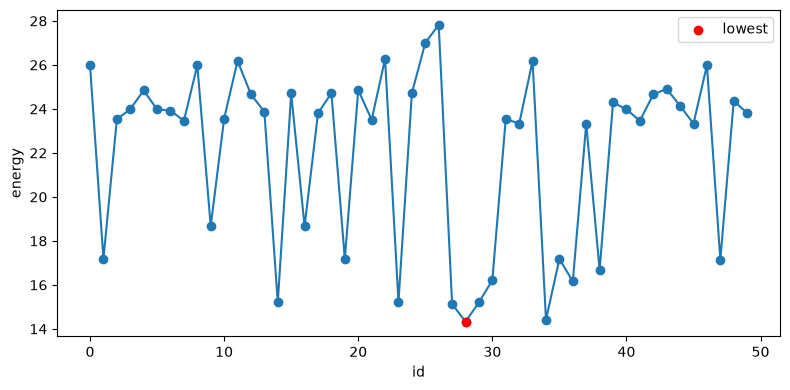

In [4]:
# matplotlibのinstallが必要。
import matplotlib.pyplot as plt

ids = list(conf_ids)
plt.figure(figsize=(8, 4))
plt.plot(ids, energies, marker="o")
plt.scatter([min_conf_id], [min(energies)], color="red", zorder=3, label="lowest")
plt.xlabel("id")
plt.ylabel("energy")
plt.legend()
plt.tight_layout()
plt.show()


例2で molファイルとしてエクスポートする場合は以下を追加  
```python
Chem.MolToMolFile(best, "lowest_energy.mol")
```

再安定化構造を図示する場合は以下。  

In [5]:
from molaspect import view_aspect3d

view_aspect3d(mol=best)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.